In [1]:
# Step 1 Importing libraries

import numpy as np         
import pandas as pd       

#Visualization
import matplotlib.pyplot as plt        
import matplotlib.patches as mpatches  
import seaborn as sns                 

# Machine Learning 
from sklearn.preprocessing import StandardScaler      
from sklearn.decomposition import PCA                 
from sklearn.linear_model import LogisticRegression   # our ML model
from sklearn.model_selection import train_test_split  
from sklearn.metrics import accuracy_score            
from sklearn.metrics import classification_report     

# Other 
import time
import warnings
warnings.filterwarnings('ignore')

#Plot settings 
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("All libraries imported successfully!")
print(f"   NumPy version:  {np.__version__}")
print(f"   Pandas version: {pd.__version__}")

All libraries imported successfully!
   NumPy version:  2.4.4
   Pandas version: 3.0.2


In [2]:
# Step 2 Loading Data

df = pd.read_csv("/Users/yubrajparajuli/Downloads/pca-wine-quality/data/WineQT.csv")

In [3]:
df.shape

(1143, 13)

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [5]:
null_table = pd.DataFrame({
    'null_count' : df.isnull().sum(),
    'null_percentage': df.isnull().mean()*100
})
print(null_table)

                      null_count  null_percentage
fixed acidity                  0              0.0
volatile acidity               0              0.0
citric acid                    0              0.0
residual sugar                 0              0.0
chlorides                      0              0.0
free sulfur dioxide            0              0.0
total sulfur dioxide           0              0.0
density                        0              0.0
pH                             0              0.0
sulphates                      0              0.0
alcohol                        0              0.0
quality                        0              0.0
Id                             0              0.0


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [7]:
# Clean column names — lowercase, no spaces
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

In [8]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [9]:
# Dropping id columns

df = df.drop(columns = 'id')

In [10]:
df.shape

(1143, 12)

In [11]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [12]:
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

In [13]:
# --- Create binary target ---
# Quality 3, 4, 5 → Bad wine  → 0
# Quality 6, 7, 8 → Good wine → 1
df['target'] = (df['quality'] >= 6).astype(int)

print("\nBinary Target Created:")
print(f"  Bad wine  (quality ≤ 5) → 0 : {(df['target'] == 0).sum()} samples")
print(f"  Good wine (quality ≥ 6) → 1 : {(df['target'] == 1).sum()} samples")

# --- Separate features and target ---
X = df.drop(columns=['quality', 'target'])
y = df['target']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target   (y) shape: {y.shape}")


Binary Target Created:
  Bad wine  (quality ≤ 5) → 0 : 522 samples
  Good wine (quality ≥ 6) → 1 : 621 samples

Features (X) shape: (1143, 11)
Target   (y) shape: (1143,)


In [14]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [15]:
y.head()

0    0
1    0
2    0
3    1
4    0
Name: target, dtype: int64

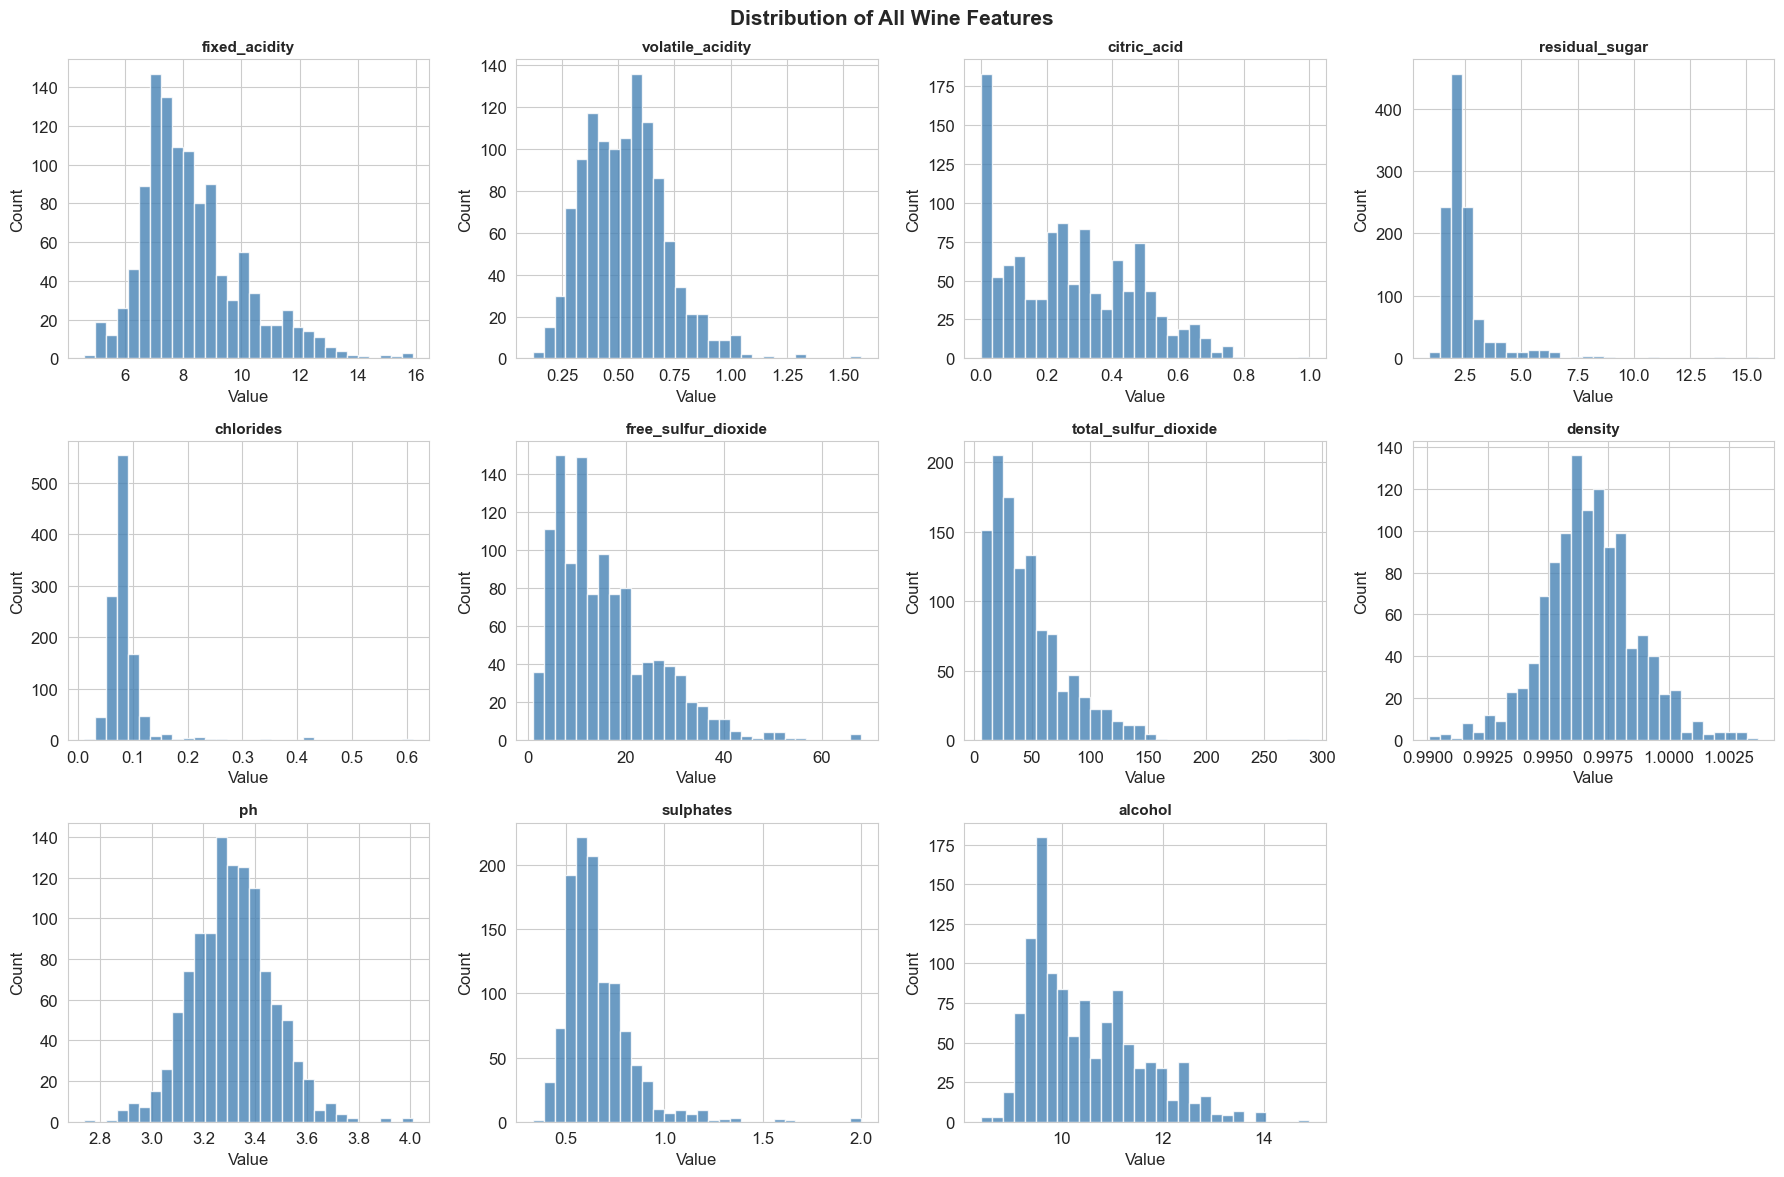

Plot 1 done: Feature Distributions


In [16]:
# step 3 EDA

#   1. FEATURE DISTRIBUTIONS

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=30, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide last empty subplot because we have 11 features but 12 subplots
axes[-1].set_visible(False)

plt.suptitle('Distribution of All Wine Features',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/01_feature_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 done: Feature Distributions")

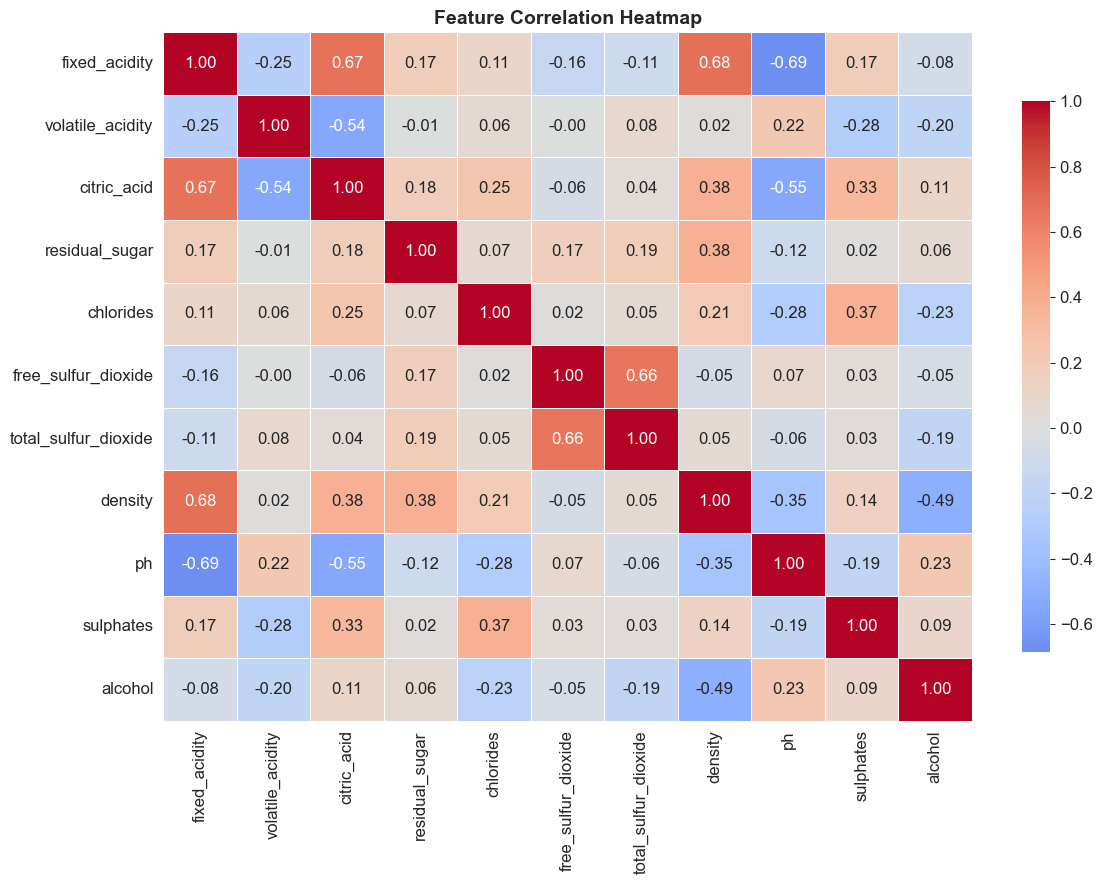

Plot 2 done: Correlation Heatmap


In [19]:

#CORRELATION HEATMAP


fig, ax = plt.subplots(figsize=(12, 9))

# Calculate correlation matrix
corr = X.corr()

# Create heatmap
sns.heatmap(
    corr,
    annot=True,           # show numbers inside each cell
    fmt='.2f',            # round to 2 decimal places
    cmap='coolwarm',      # red = positive, blue = negative correlation
    center=0,             # white = zero correlation
    ax=ax,
    linewidths=0.5,       # lines between cells
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Feature Correlation Heatmap',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/02_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 done: Correlation Heatmap")

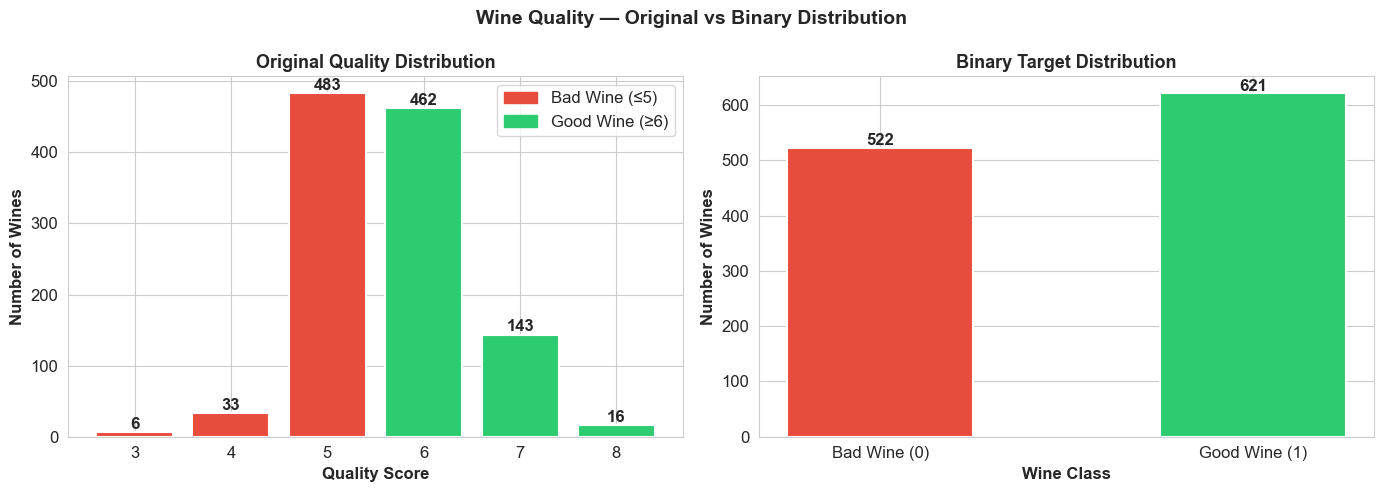

Plot 3 done: Quality Distribution


In [20]:
# Quality Distribution Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Original quality scores ---
colors = ['#e74c3c' if q <= 5 else '#2ecc71' 
          for q in sorted(df['quality'].unique())]
quality_counts = df['quality'].value_counts().sort_index()

bars = axes[0].bar(quality_counts.index, quality_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5)

axes[0].set_xlabel('Quality Score', fontweight='bold')
axes[0].set_ylabel('Number of Wines', fontweight='bold')
axes[0].set_title('Original Quality Distribution', 
                  fontsize=13, fontweight='bold')

# Add count labels on top of each bar
for bar, count in zip(bars, quality_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold')

red_patch   = mpatches.Patch(color='#e74c3c', label='Bad Wine (≤5)')
green_patch = mpatches.Patch(color='#2ecc71', label='Good Wine (≥6)')
axes[0].legend(handles=[red_patch, green_patch])

# --- Right plot: Binary target distribution ---
binary_counts = df['target'].value_counts().sort_index()
binary_labels = ['Bad Wine (0)', 'Good Wine (1)']
binary_colors = ['#e74c3c', '#2ecc71']

bars2 = axes[1].bar(binary_labels, binary_counts.values,
                    color=binary_colors, edgecolor='white', 
                    linewidth=1.5, width=0.5)

axes[1].set_xlabel('Wine Class', fontweight='bold')
axes[1].set_ylabel('Number of Wines', fontweight='bold')
axes[1].set_title('Binary Target Distribution',
                  fontsize=13, fontweight='bold')

# Add count labels
for bar, count in zip(bars2, binary_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold')

plt.suptitle('Wine Quality — Original vs Binary Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_quality_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 done: Quality Distribution")

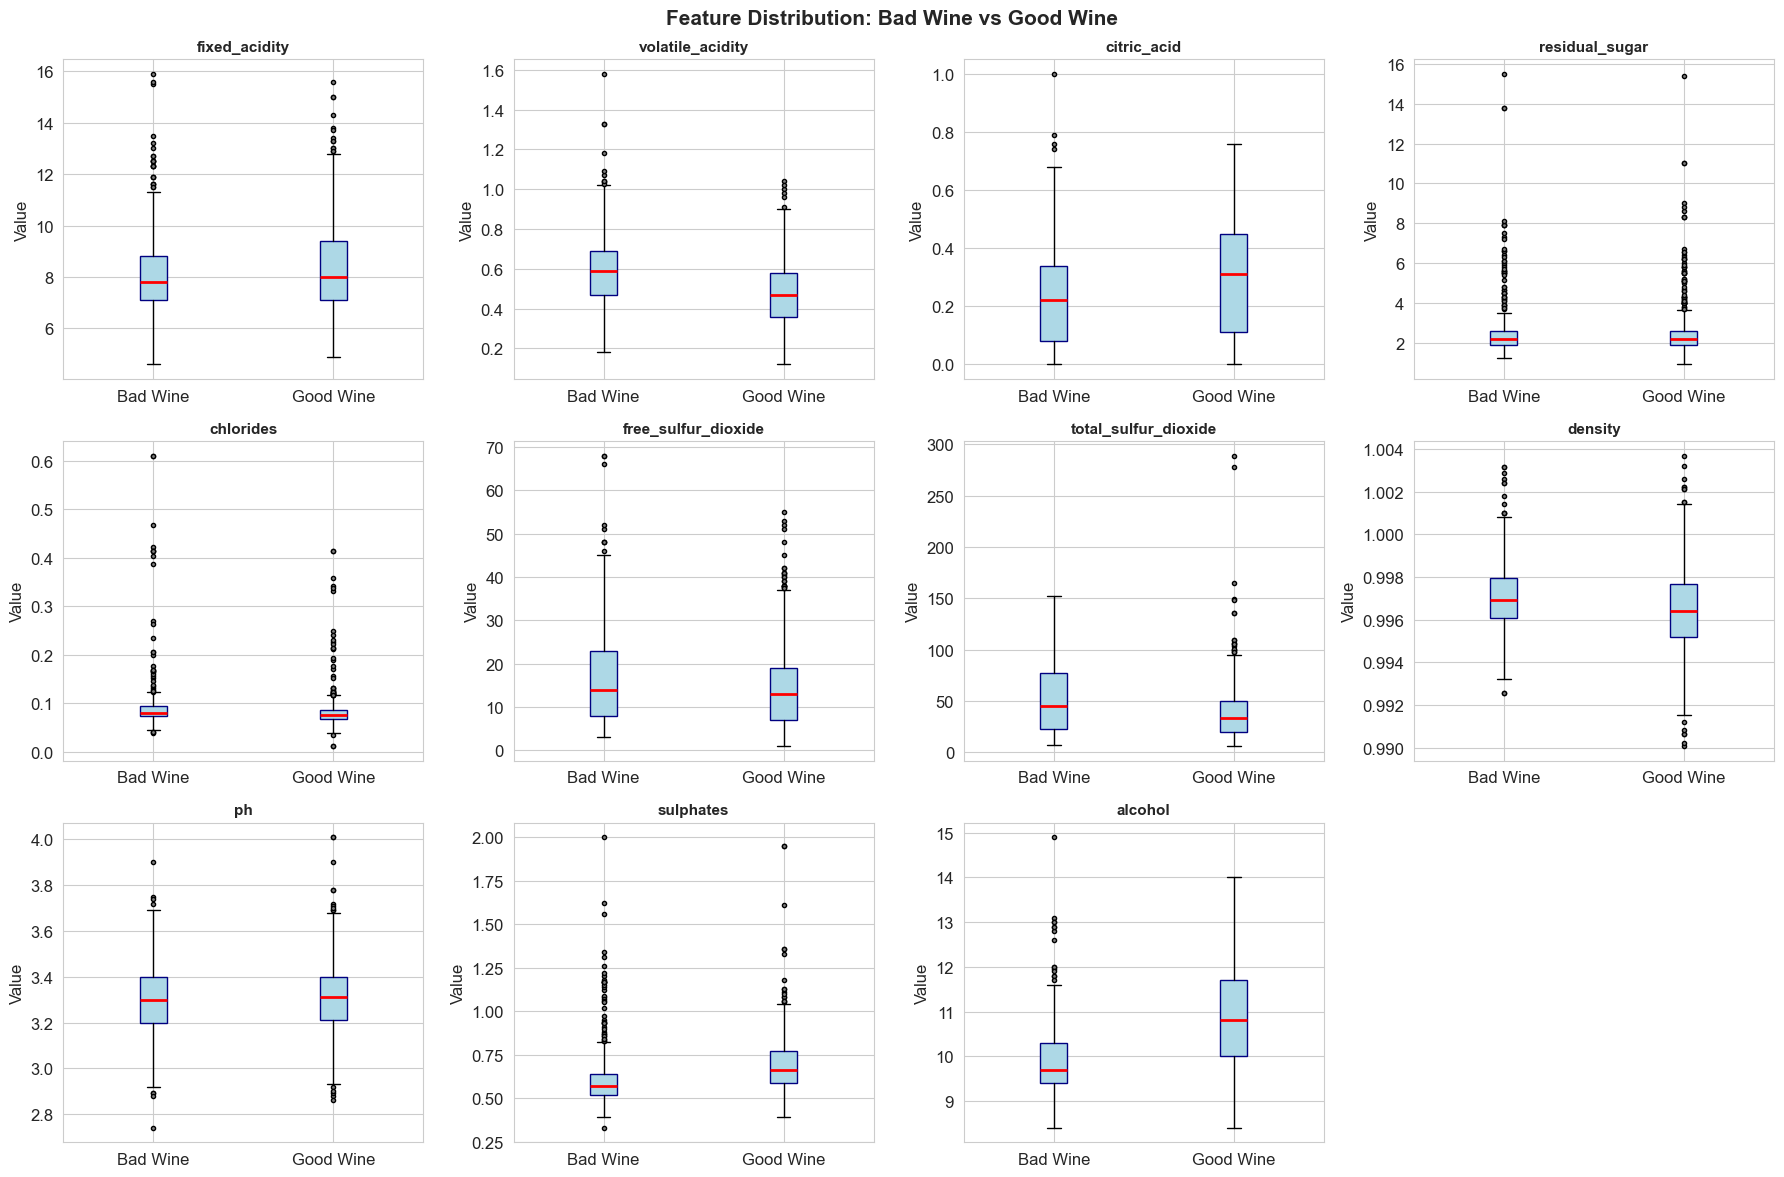

 Plot 4 done: Boxplot Features vs Target


In [21]:
# Boxplot Features vs Target

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    # Plot bad wine (0) and good wine (1) side by side
    bad_wine  = X[col][y == 0]
    good_wine = X[col][y == 1]

    axes[i].boxplot([bad_wine, good_wine],
                    labels=['Bad Wine', 'Good Wine'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, 
                                   markerfacecolor='gray'))

    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

# Hide last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Feature Distribution: Bad Wine vs Good Wine',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/04_boxplot_features_vs_target.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Plot 4 done: Boxplot Features vs Target")

In [22]:

# STANDARDIZE THE DATA


from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit and transform the features
# fit()      → calculates mean and std of each feature
# transform() → subtracts mean and divides by std
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# --- Verify standardization worked ---
print("BEFORE Standardization:")
print(f"  fixed_acidity  → mean: {X['fixed_acidity'].mean():.4f}, std: {X['fixed_acidity'].std():.4f}")
print(f"  alcohol        → mean: {X['alcohol'].mean():.4f}, std: {X['alcohol'].std():.4f}")
print(f"  total_sulfur_dioxide → mean: {X['total_sulfur_dioxide'].mean():.4f}, std: {X['total_sulfur_dioxide'].std():.4f}")

print("\nAFTER Standardization:")
print(f"  fixed_acidity  → mean: {X_scaled_df['fixed_acidity'].mean():.4f}, std: {X_scaled_df['fixed_acidity'].std():.4f}")
print(f"  alcohol        → mean: {X_scaled_df['alcohol'].mean():.4f}, std: {X_scaled_df['alcohol'].std():.4f}")
print(f"  total_sulfur_dioxide → mean: {X_scaled_df['total_sulfur_dioxide'].mean():.4f}, std: {X_scaled_df['total_sulfur_dioxide'].std():.4f}")

print(f"\nX_scaled shape: {X_scaled.shape}")
print("\nStandardization complete!")
print("   Every feature now has mean ≈ 0 and std ≈ 1")

BEFORE Standardization:
  fixed_acidity  → mean: 8.3111, std: 1.7476
  alcohol        → mean: 10.4421, std: 1.0822
  total_sulfur_dioxide → mean: 45.9147, std: 32.7821

AFTER Standardization:
  fixed_acidity  → mean: -0.0000, std: 1.0004
  alcohol        → mean: -0.0000, std: 1.0004
  total_sulfur_dioxide → mean: 0.0000, std: 1.0004

X_scaled shape: (1143, 11)

Standardization complete!
   Every feature now has mean ≈ 0 and std ≈ 1


In [23]:
#step 4 PCA FROM SCRATCH

#step A : Centering the data

# Calculate mean of each feature
mean = np.mean(X_scaled, axis=0)

# Subtract mean from every row
# This moves the entire data cloud to origin (0,0)
X_centered = X_scaled - mean

print("Mean of each feature BEFORE centering:")
print(np.round(mean[:5], 6), "...")

print("\nMean of each feature AFTER centering:")
print(np.round(X_centered.mean(axis=0)[:5], 6), "...")

print(f"\nX_centered shape: {X_centered.shape}")
print(" Step A done: Data Centered!")

Mean of each feature BEFORE centering:
[-0.  0.  0.  0.  0.] ...

Mean of each feature AFTER centering:
[0. 0. 0. 0. 0.] ...

X_centered shape: (1143, 11)
 Step A done: Data Centered!


In [24]:

#   Step B: Compute Covariance Matrix

n_samples = X_centered.shape[0]

# Covariance matrix formula:
# C = (X^T · X) / (n - 1)
cov_matrix = np.dot(X_centered.T, X_centered) / (n_samples - 1)

print(f"Number of samples: {n_samples}")
print(f"\nCovariance Matrix Shape: {cov_matrix.shape}")
print(f"\nCovariance Matrix (first 4x4):")
print(np.round(cov_matrix[:4, :4], 4))

print("\nDiagonal values (variance of each feature):")
for i, col in enumerate(X.columns):
    print(f"  {col:<25} → variance: {cov_matrix[i,i]:.4f}")

print("\n Step B done: Covariance Matrix computed!")

Number of samples: 1143

Covariance Matrix Shape: (11, 11)

Covariance Matrix (first 4x4):
[[ 1.0009 -0.2509  0.6737  0.172 ]
 [-0.2509  1.0009 -0.5447 -0.0058]
 [ 0.6737 -0.5447  1.0009  0.176 ]
 [ 0.172  -0.0058  0.176   1.0009]]

Diagonal values (variance of each feature):
  fixed_acidity             → variance: 1.0009
  volatile_acidity          → variance: 1.0009
  citric_acid               → variance: 1.0009
  residual_sugar            → variance: 1.0009
  chlorides                 → variance: 1.0009
  free_sulfur_dioxide       → variance: 1.0009
  total_sulfur_dioxide      → variance: 1.0009
  density                   → variance: 1.0009
  ph                        → variance: 1.0009
  sulphates                 → variance: 1.0009
  alcohol                   → variance: 1.0009

 Step B done: Covariance Matrix computed!


In [26]:

#   Step C: Compute Eigenvectors and Eigenvalues

# Compute eigenvectors and eigenvalues from covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Keep only real parts
# (tiny imaginary parts appear due to floating point precision)
eigenvalues  = eigenvalues.real
eigenvectors = eigenvectors.real

print("Eigenvalues (unsorted):")
print(np.round(eigenvalues, 4))

print(f"\nEigenvectors shape: {eigenvectors.shape}")

print(f"\nSum of all eigenvalues: {eigenvalues.sum():.4f}")
print(f"Number of features:     {X_scaled.shape[1]}")
print("\nStep C done: Eigenvectors and Eigenvalues computed!")

Eigenvalues (unsorted):
[3.1589 1.8799 1.575  1.2126 0.9591 0.0585 0.1774 0.666  0.5581 0.3448
 0.4194]

Eigenvectors shape: (11, 11)

Sum of all eigenvalues: 11.0096
Number of features:     11

Step C done: Eigenvectors and Eigenvalues computed!


In [28]:

#   Step D: Sort and Select Components
# --- Sort eigenvalues from largest to smallest ---
sorted_idx   = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# --- Calculate explained variance ratio ---
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance      = np.cumsum(explained_variance_ratio)

# --- Print results ---
print(f"{'Component':<12} {'Eigenvalue':<12} {'Explained Var':<15} {'Cumulative'}")
print("-" * 52)
for i in range(len(eigenvalues)):
    print(f"PC{i+1:<10} {eigenvalues[i]:<12.4f} "
          f"{str(round(explained_variance_ratio[i]*100, 2))+'%':<15}"
          f"{cumulative_variance[i]*100:.2f}%")

# --- Select number of components ---
# We want to retain at least 80% of variance
n_components = np.argmax(cumulative_variance >= 0.80) + 1
print(f"\nComponents needed for 80% variance: {n_components}")
print(f"   Variance retained: {cumulative_variance[n_components-1]*100:.2f}%")

Component    Eigenvalue   Explained Var   Cumulative
----------------------------------------------------
PC1          3.1589       28.69%         28.69%
PC2          1.8799       17.08%         45.77%
PC3          1.5750       14.31%         60.07%
PC4          1.2126       11.01%         71.09%
PC5          0.9591       8.71%          79.80%
PC6          0.6660       6.05%          85.85%
PC7          0.5581       5.07%          90.92%
PC8          0.4194       3.81%          94.73%
PC9          0.3448       3.13%          97.86%
PC10         0.1774       1.61%          99.47%
PC11         0.0585       0.53%          100.00%

Components needed for 80% variance: 6
   Variance retained: 85.85%


In [29]:

#   Step E: Project Data onto Principal Components

# We take only top 6 eigenvectors
# These are our 6 principal components
# Shape: (11, 6) — 11 features, 6 components
W = eigenvectors[:, :n_components]

print(f"Projection matrix W shape: {W.shape}")
print("(11 features × 6 components)")

# Project data onto principal components
# Matrix multiplication: (1143 × 11) · (11 × 6) = (1143 × 6)
X_pca_scratch = np.dot(X_centered, W)

print(f"\nOriginal data shape:    {X_scaled.shape}")
print(f"Transformed data shape: {X_pca_scratch.shape}")

print(f"\nFirst wine sample BEFORE PCA (11 values):")
print(np.round(X_scaled[0], 4))

print(f"\nFirst wine sample AFTER PCA (6 values):")
print(np.round(X_pca_scratch[0], 4))

print("\n Step E done: Data Projected!")
print(f"   Reduced from {X_scaled.shape[1]} features → {n_components} components")
print(f"   Variance retained: {cumulative_variance[n_components-1]*100:.2f}%")

Projection matrix W shape: (11, 6)
(11 features × 6 components)

Original data shape:    (1143, 11)
Transformed data shape: (1143, 6)

First wine sample BEFORE PCA (11 values):
[-0.5216  0.9393 -1.365  -0.4664 -0.2314 -0.4505 -0.3636  0.5559  1.2707
 -0.5737 -0.9634]

First wine sample AFTER PCA (6 values):
[ 1.5615 -0.4449  1.7672 -0.1326 -0.1301 -0.9068]

 Step E done: Data Projected!
   Reduced from 11 features → 6 components
   Variance retained: 85.85%


In [30]:

#step 5 VERIFY WITH SKLEARN PCA


from sklearn.decomposition import PCA

# Create PCA object with same number of components
pca_sklearn = PCA(n_components=n_components)

# Fit and transform in one step
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled)

print("Sklearn PCA Results:")
print(f"  Input shape:  {X_scaled.shape}")
print(f"  Output shape: {X_pca_sklearn.shape}")

print(f"\n{'Component':<12} {'Sklearn Var':<15} {'Scratch Var':<15} {'Match?'}")
print("-" * 55)
for i in range(n_components):
    sklearn_var = pca_sklearn.explained_variance_ratio_[i] * 100
    scratch_var = explained_variance_ratio[i] * 100
    match = "OK" if abs(sklearn_var - scratch_var) < 0.1 else "MISMATCH"
    print(f"PC{i+1:<10} {sklearn_var:<15.2f} {scratch_var:<15.2f} {match}")

print(f"\nSklearn cumulative variance: "
      f"{pca_sklearn.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Scratch cumulative variance: "
      f"{cumulative_variance[n_components-1]*100:.2f}%")

# Compare actual transformed values
diff = np.mean(np.abs(np.abs(X_pca_sklearn) - np.abs(X_pca_scratch)))
print(f"\nAverage difference between scratch and sklearn: {diff:.6f}")

if diff < 0.01:
    print("Verified: PCA from scratch matches sklearn perfectly!")
else:
    print("Warning: Small difference found — check implementation")

Sklearn PCA Results:
  Input shape:  (1143, 11)
  Output shape: (1143, 6)

Component    Sklearn Var     Scratch Var     Match?
-------------------------------------------------------
PC1          28.69           28.69           OK
PC2          17.08           17.08           OK
PC3          14.31           14.31           OK
PC4          11.01           11.01           OK
PC5          8.71            8.71            OK
PC6          6.05            6.05            OK

Sklearn cumulative variance: 85.85%
Scratch cumulative variance: 85.85%

Average difference between scratch and sklearn: 0.000000
Verified: PCA from scratch matches sklearn perfectly!


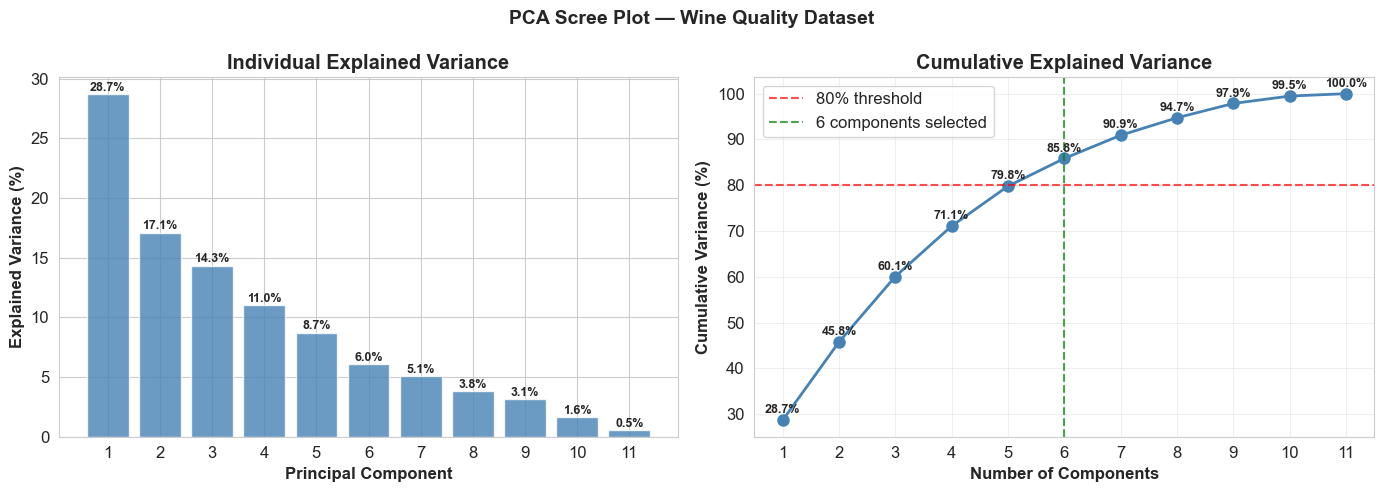

Scree plot saved!


In [31]:

#  Step 6— PCA VISUALIZATIONS
#   Plot 1: Scree Plot


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Individual explained variance ---
axes[0].bar(range(1, len(eigenvalues)+1),
            explained_variance_ratio * 100,
            color='steelblue', edgecolor='white',
            alpha=0.8)

# Add value labels on top of each bar
for i, var in enumerate(explained_variance_ratio):
    axes[0].text(i+1, var*100 + 0.3,
                 f'{var*100:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

axes[0].set_xlabel('Principal Component', fontweight='bold')
axes[0].set_ylabel('Explained Variance (%)', fontweight='bold')
axes[0].set_title('Individual Explained Variance', fontweight='bold')
axes[0].set_xticks(range(1, len(eigenvalues)+1))

# --- Right plot: Cumulative explained variance ---
axes[1].plot(range(1, len(eigenvalues)+1),
             cumulative_variance * 100,
             'o-', color='steelblue',
             linewidth=2, markersize=8)

# Add 80% threshold line
axes[1].axhline(y=80, color='red', linestyle='--',
                alpha=0.7, label='80% threshold')

# Add vertical line at selected components
axes[1].axvline(x=n_components, color='green',
                linestyle='--', alpha=0.7,
                label=f'{n_components} components selected')

# Add value labels on each point
for i, var in enumerate(cumulative_variance):
    axes[1].text(i+1, var*100 + 1.5,
                 f'{var*100:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Variance (%)', fontweight='bold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xticks(range(1, len(eigenvalues)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Scree Plot — Wine Quality Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/05_scree_plot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Scree plot saved!")

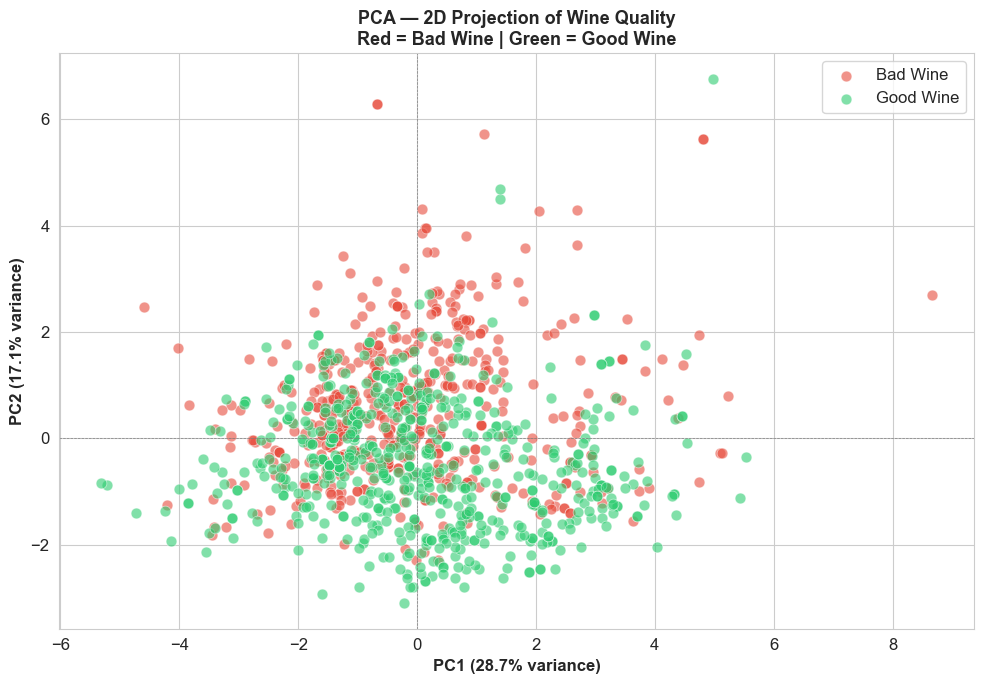

2D scatter plot saved!


In [32]:
#   Plot 2: 2D PCA Scatter Plot


fig, ax = plt.subplots(figsize=(10, 7))

# Define colors and labels
colors = {0: '#e74c3c', 1: '#2ecc71'}
labels = {0: 'Bad Wine', 1: 'Good Wine'}

# Plot each class separately
for cls in [0, 1]:
    mask = y == cls
    ax.scatter(
        X_pca_sklearn[mask, 0],   # PC1 on x axis
        X_pca_sklearn[mask, 1],   # PC2 on y axis
        c=colors[cls],
        label=labels[cls],
        alpha=0.6,
        edgecolors='white',
        linewidth=0.5,
        s=60
    )

ax.set_xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]*100:.1f}% variance)',
              fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]*100:.1f}% variance)',
              fontweight='bold')
ax.set_title('PCA — 2D Projection of Wine Quality\n'
             'Red = Bad Wine | Green = Good Wine',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/06_pca_2d_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("2D scatter plot saved!")

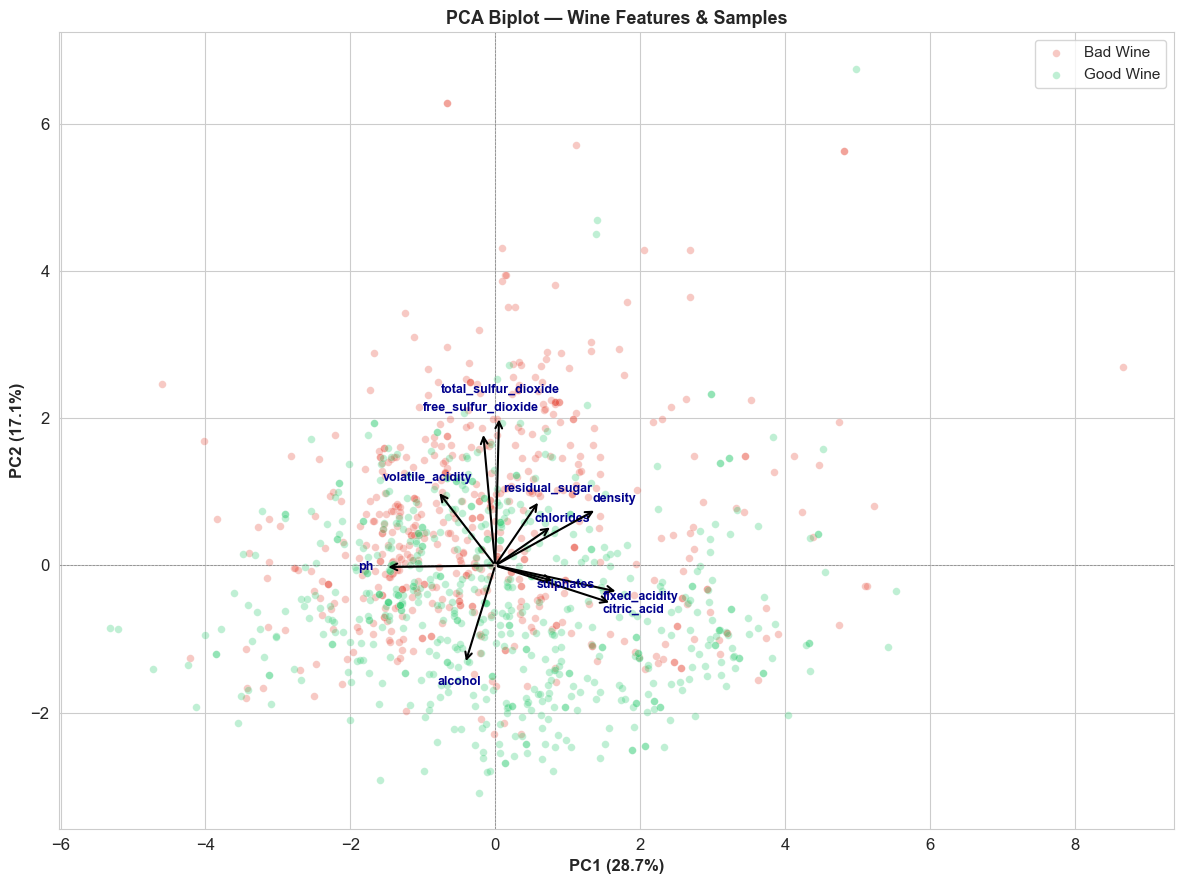

Biplot saved!


In [33]:
#   Plot 3: Biplot

fig, ax = plt.subplots(figsize=(12, 9))

# --- Plot data points ---
for cls in [0, 1]:
    mask = y == cls
    ax.scatter(
        X_pca_sklearn[mask, 0],
        X_pca_sklearn[mask, 1],
        c=colors[cls],
        alpha=0.3,
        s=30,
        edgecolors='white',
        linewidth=0.3,
        label=labels[cls]
    )

# --- Plot feature arrows ---
components = pca_sklearn.components_
scale = 3.5

for i, feature in enumerate(X.columns):
    ax.annotate('',
                xy=(components[0, i] * scale,
                    components[1, i] * scale),
                xytext=(0, 0),
                arrowprops=dict(
                    arrowstyle='->',
                    color='black',
                    lw=1.5
                ))
    ax.text(components[0, i] * scale * 1.18,
            components[1, i] * scale * 1.18,
            feature, fontsize=9,
            fontweight='bold', color='darkblue',
            ha='center', va='center')

ax.set_xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]*100:.1f}%)',
              fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]*100:.1f}%)',
              fontweight='bold')
ax.set_title('PCA Biplot — Wine Features & Samples',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/07_biplot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Biplot saved!")

In [34]:
#step 7 ML model


# LOGISTIC REGRESSION BEFORE PCA

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# --- Split original full data ---
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps same class ratio in train and test
)

print("Data Split:")
print(f"  Training samples: {X_train_full.shape[0]}")
print(f"  Testing samples:  {X_test_full.shape[0]}")
print(f"  Features used:    {X_train_full.shape[1]}")

# --- Train model ---
model_full = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
model_full.fit(X_train_full, y_train)
end_time = time.time()

training_time_full = end_time - start_time

# --- Evaluate model ---
y_pred_full = model_full.predict(X_test_full)
accuracy_full = accuracy_score(y_test, y_pred_full)

print(f"\nModel Results BEFORE PCA:")
print(f"  Features used:   {X_train_full.shape[1]}")
print(f"  Training time:   {training_time_full:.5f} seconds")
print(f"  Accuracy:        {accuracy_full*100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred_full,
      target_names=['Bad Wine', 'Good Wine']))

Data Split:
  Training samples: 914
  Testing samples:  229
  Features used:    11

Model Results BEFORE PCA:
  Features used:   11
  Training time:   0.11795 seconds
  Accuracy:        77.73%

Detailed Report:
              precision    recall  f1-score   support

    Bad Wine       0.75      0.77      0.76       105
   Good Wine       0.80      0.78      0.79       124

    accuracy                           0.78       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.78      0.78      0.78       229



In [35]:
#   Step 8 — LOGISTIC REGRESSION AFTER PCA

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_sklearn, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Split:")
print(f"  Training samples: {X_train_pca.shape[0]}")
print(f"  Testing samples:  {X_test_pca.shape[0]}")
print(f"  Features used:    {X_train_pca.shape[1]} (PCA components)")

# Train model
model_pca = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
model_pca.fit(X_train_pca, y_train_pca)
end_time = time.time()

training_time_pca = end_time - start_time

# Evaluate model
y_pred_pca = model_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print(f"\nModel Results AFTER PCA:")
print(f"  Components used: {X_train_pca.shape[1]}")
print(f"  Training time:   {training_time_pca:.5f} seconds")
print(f"  Accuracy:        {accuracy_pca*100:.2f}%")

print("\nDetailed Report:")
print(classification_report(y_test_pca, y_pred_pca,
      target_names=['Bad Wine', 'Good Wine']))

Data Split:
  Training samples: 914
  Testing samples:  229
  Features used:    6 (PCA components)

Model Results AFTER PCA:
  Components used: 6
  Training time:   0.00361 seconds
  Accuracy:        77.29%

Detailed Report:
              precision    recall  f1-score   support

    Bad Wine       0.76      0.74      0.75       105
   Good Wine       0.79      0.80      0.79       124

    accuracy                           0.77       229
   macro avg       0.77      0.77      0.77       229
weighted avg       0.77      0.77      0.77       229



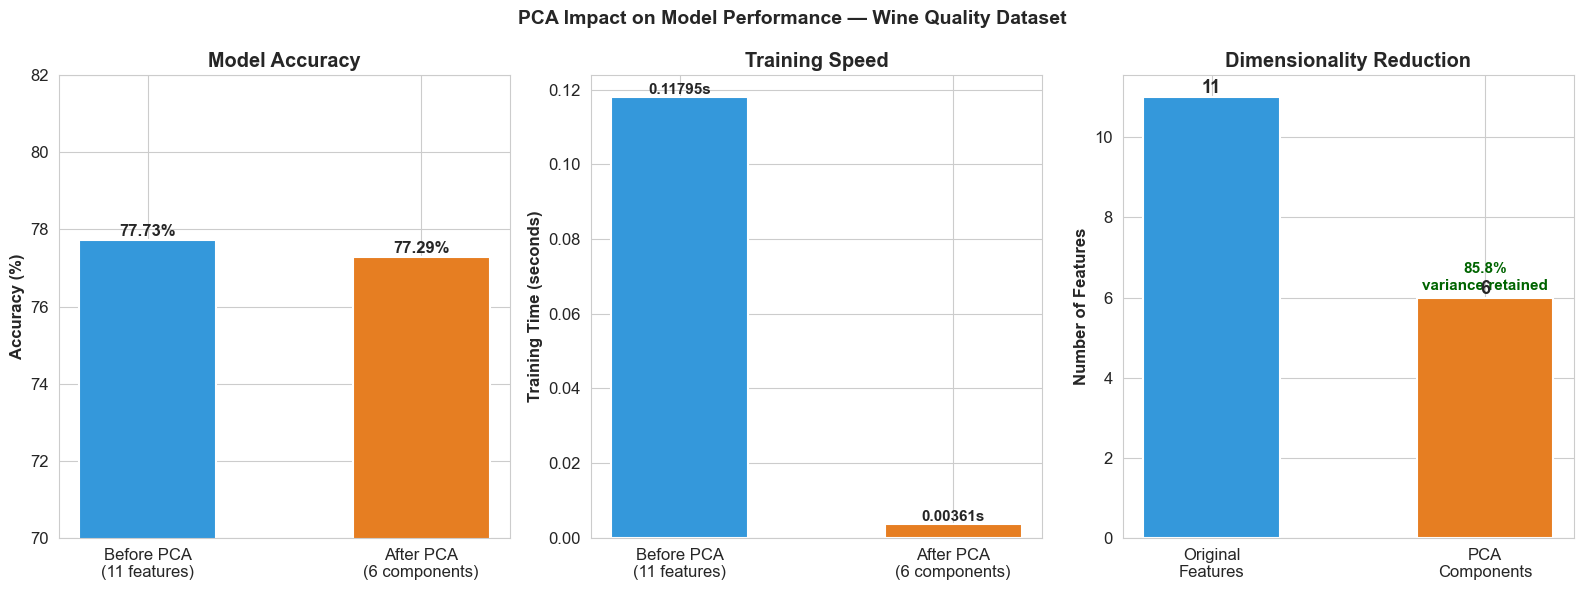

Final comparison plot saved!


In [36]:
#step 9 FINAL COMPARISON VISUALIZATION

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# --- Plot 1: Accuracy Comparison ---
accuracy_values = [accuracy_full * 100, accuracy_pca * 100]
bars1 = axes[0].bar(
    ['Before PCA\n(11 features)', 'After PCA\n(6 components)'],
    accuracy_values,
    color=['#3498db', '#e67e22'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[0].set_ylabel('Accuracy (%)', fontweight='bold')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_ylim([70, 82])
for bar, val in zip(bars1, accuracy_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.2f}%',
                 ha='center', fontweight='bold', fontsize=12)

# --- Plot 2: Training Time Comparison ---
time_values = [training_time_full, training_time_pca]
bars2 = axes[1].bar(
    ['Before PCA\n(11 features)', 'After PCA\n(6 components)'],
    time_values,
    color=['#3498db', '#e67e22'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[1].set_ylabel('Training Time (seconds)', fontweight='bold')
axes[1].set_title('Training Speed', fontweight='bold')
for bar, val in zip(bars2, time_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.5f}s',
                 ha='center', fontweight='bold', fontsize=11)

# --- Plot 3: Features vs Variance Retained ---
axes[2].bar(
    ['Original\nFeatures', 'PCA\nComponents'],
    [11, n_components],
    color=['#3498db', '#e67e22'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
axes[2].set_ylabel('Number of Features', fontweight='bold')
axes[2].set_title('Dimensionality Reduction', fontweight='bold')

# Add variance retained annotation
axes[2].text(1, n_components + 0.2,
             f'{cumulative_variance[n_components-1]*100:.1f}%\nvariance retained',
             ha='center', fontweight='bold',
             fontsize=11, color='darkgreen')

for bar, val in zip(axes[2].patches, [11, n_components]):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 str(val),
                 ha='center', fontweight='bold', fontsize=13)

plt.suptitle('PCA Impact on Model Performance — Wine Quality Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/08_final_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Final comparison plot saved!")